In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/finaltask/test.pickle
/kaggle/input/finaltask/generated_data.pickle
/kaggle/input/finaltask/train.pickle
/kaggle/input/finaltask/gan_model.pth


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_pickle('/kaggle/input/finaltask/test.pickle')

In [4]:
# Display first few rows
display(df.head())

# Basic info
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

,sensor_data,label,model,velocity,mass,deceleration_average
0,"[[-3.9346010604972648, -0.05542138047796165, -...",0,Variant Comfortline,30,1530.0,-3.393840
1,"[[-3.4810850496899266, 0.06682498013278597, -0...",0,Variant Comfortline,30,1530.0,-3.062394
2,"[[-3.8058791698213876, 0.059129464753241476, -...",0,Variant Comfortline,30,1530.0,-3.241874
3,"[[-3.056437445215012, -0.0169762924105487, 0.0...",0,Variant Comfortline,30,1530.0,-3.053816
4,"[[-3.183553735242826, 0.03141200276945951, -0....",0,Variant Comfortline,30,1530.0,-2.872724



Shape: (1001, 6)

Data Types:
 sensor_data              object
label                     int64
model                    object
velocity                  int64
mass                    float64
deceleration_average    float64
dtype: object

Missing Values:
 sensor_data               0
label                     0
model                     0
velocity                  0
mass                    456
deceleration_average      0
dtype: int64


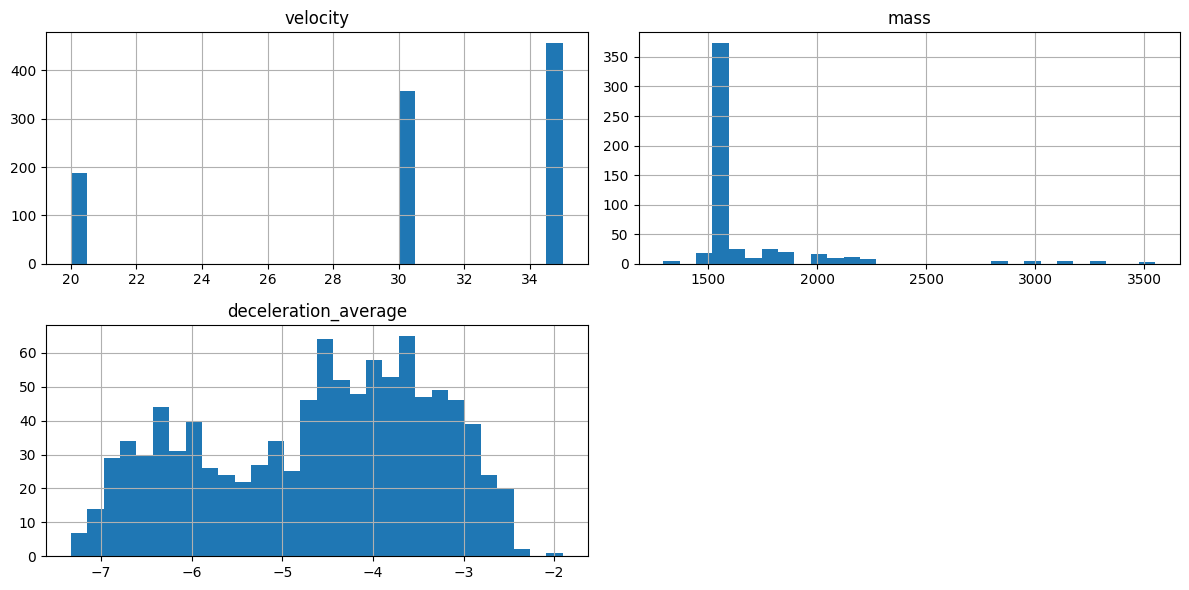

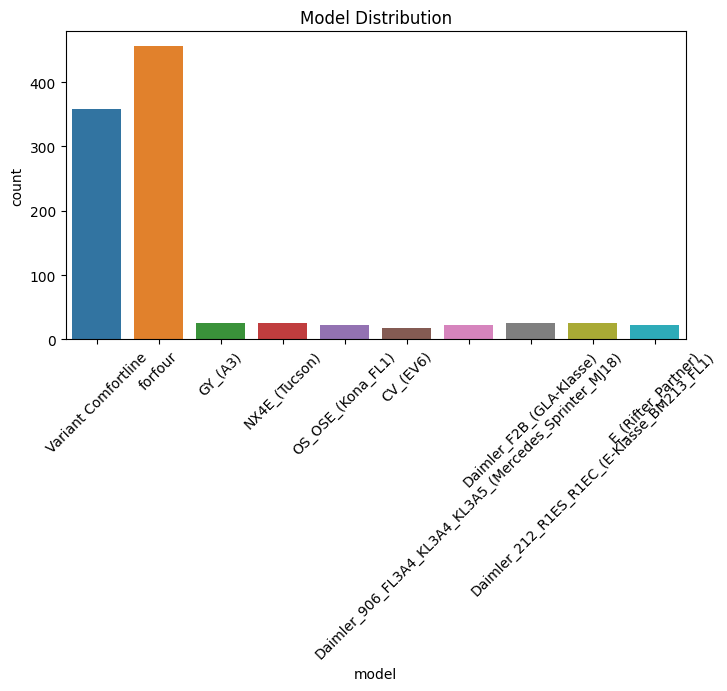

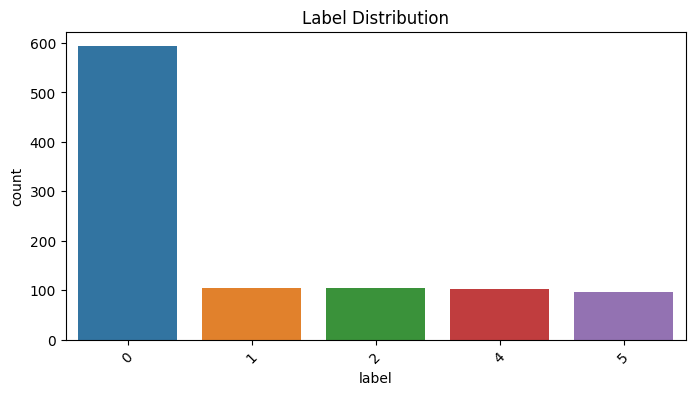

In [5]:
# Plot histograms for numerical features
df[['velocity', 'mass', 'deceleration_average']].hist(figsize=(12, 6), bins=30)
plt.tight_layout()
plt.show()

# Countplot for model distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='model', data=df)
plt.title('Model Distribution')
plt.xticks(rotation=45)
plt.show()

# Countplot for label distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.xticks(rotation=45)
plt.show()

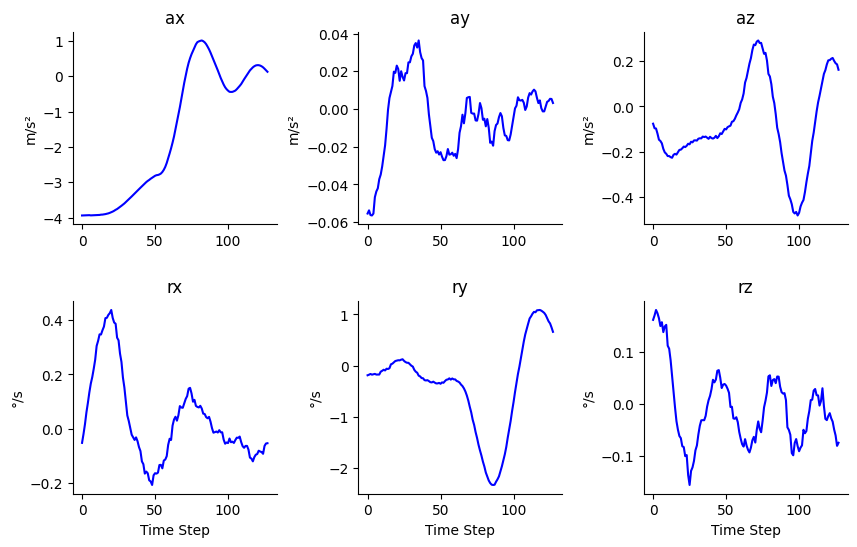

In [6]:
def plot_drive_data(data: np.ndarray) -> None:


    # Labels for the 6 sensor signals
    labels = ['ax', 'ay', 'az', 'rx', 'ry', 'rz']

    # Create figure and 2x3 subplots
    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))

    # Loop over each axis and sensor data to plot
    for i, ax in enumerate(axs.flat):
        # Plot the sensor data (without time)
        ax.plot(data[:, i], color='blue')

        # Set subplot title and axis labels
        ax.set_title(labels[i])
        if i < 3:
            ax.set_ylabel('m/s²')
        else:
            ax.set_ylabel('°/s')

        # Remove top and right borders for cleaner look
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        # Add x-axis label for the bottom subplots
        if i >= 3:
            ax.set_xlabel('Time Step')

    # Adjust spaces between subplots
    plt.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.show()
plot_drive_data(df.loc[0,'sensor_data'])

In [7]:
# Version checks
import sklearn
assert sklearn.__version__ >= '1.0', "scikit-learn version must be >= 1.0. Run 'pip install --upgrade scikit-learn'."
import torch
assert torch.__version__ >= '1.10', "PyTorch version must be >= 1.10. Run 'pip install --upgrade torch'."


In [8]:
import sklearn
print(sklearn.__version__)

1.6.1


In [9]:
!pip install --upgrade scikit-learn
!pip install --upgrade imbalanced-learn

  Using cached scikit_learn-1.7.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (17 kB)
Using cached scikit_learn-1.7.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.
  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached s

In [10]:

import sklearn
print(sklearn.__version__)

1.6.1


In [11]:
!pip install tqdm

Using device: cuda
Loading data...
Preprocessing data...
Balancing data...
Normalizing data...
Preparing datasets and DataLoader...
Input shape: torch.Size([1, 128, 6]), Num classes: 5
CNN2D(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.4, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.4, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool2d(output_s

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100: Train Loss=1.5199, Train Acc=0.3144, Val Loss=1.9147, Val Acc=0.2536
Epoch 2/100: Train Loss=1.3438, Train Acc=0.4609, Val Loss=1.9328, Val Acc=0.3157
No improvement in val_loss for 1 epoch(s).
Epoch 3/100: Train Loss=1.2281, Train Acc=0.5658, Val Loss=1.8875, Val Acc=0.2594
Epoch 4/100: Train Loss=1.1211, Train Acc=0.6359, Val Loss=1.9270, Val Acc=0.2656
No improvement in val_loss for 1 epoch(s).
Epoch 5/100: Train Loss=1.0268, Train Acc=0.6931, Val Loss=1.7613, Val Acc=0.2808
Epoch 6/100: Train Loss=0.9496, Train Acc=0.7256, Val Loss=1.7169, Val Acc=0.2905
Epoch 7/100: Train Loss=0.8897, Train Acc=0.7476, Val Loss=1.6387, Val Acc=0.2926
Epoch 8/100: Train Loss=0.8372, Train Acc=0.7633, Val Loss=1.5381, Val Acc=0.3172
Epoch 9/100: Train Loss=0.7889, Train Acc=0.7788, Val Loss=1.4359, Val Acc=0.3415
Epoch 10/100: Train Loss=0.7485, Train Acc=0.7902, Val Loss=1.3175, Val Acc=0.3676
Epoch 11/100: Train Loss=0.7169, Train Acc=0.7999, Val Loss=1.2058, Val Acc=0.4047
Epoch 12/1

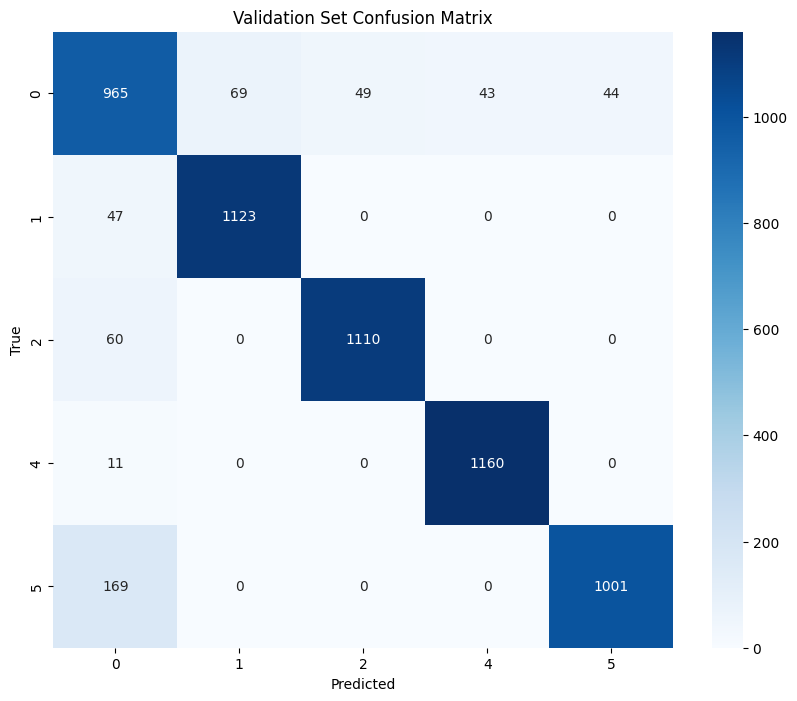

Evaluating on Test set...
=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.63      0.96      0.76       593
           1       0.80      0.04      0.07       104
           2       0.85      0.10      0.19       105
           4       0.48      0.32      0.38       103
           5       1.00      0.11      0.21        96

    accuracy                           0.63      1001
   macro avg       0.75      0.31      0.32      1001
weighted avg       0.69      0.63      0.54      1001



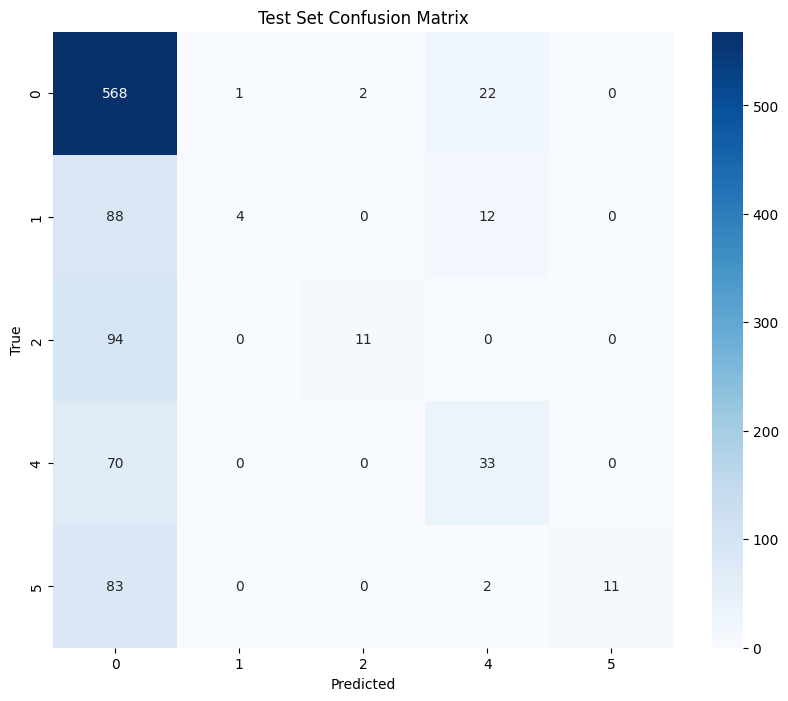

Plotting training curves...


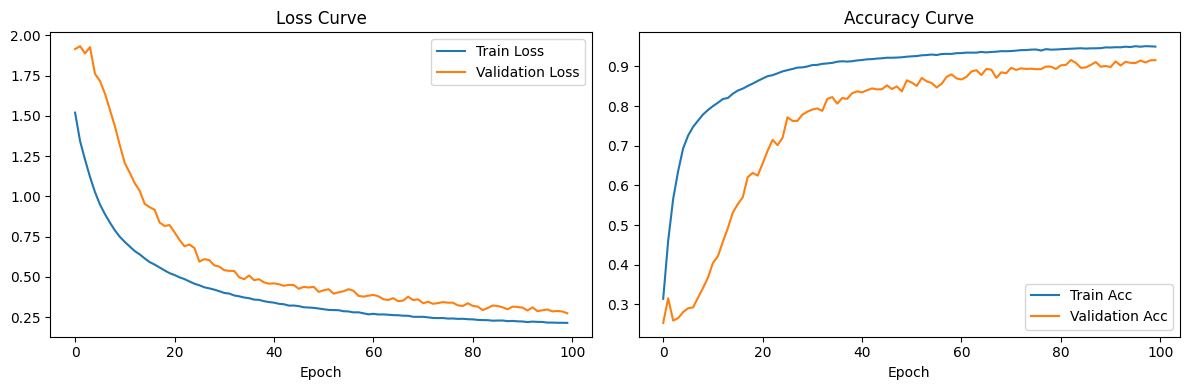

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

# 路径配置，根据实际情况修改
TRAIN_PATH = '../data/train.pickle'
TEST_PATH = '../data/input/finaltask/test.pickle'
GAN_PATH = '../data/input/finaltask/generated_data.pickle'
MODEL_SAVE = 'brake_diagnosis_2dcnn_pytorch.pth'
META_SAVE = 'meta_pytorch.pkl'

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==== 1. 加载数据 ====
def load_data():
    # 加载原始训练数据
    with open(TRAIN_PATH, 'rb') as f:
        train_data = pickle.load(f)
    x_train = np.stack(train_data['sensor_data'])
    y_train = np.array(train_data['label'])
    df_train = pd.DataFrame({
        'sensor_data': list(x_train),
        'label': y_train
    })
    
    # 加载GAN生成数据
    with open(GAN_PATH, 'rb') as f:
        gan_data = pickle.load(f)
    x_gan = np.array([item['sensor_data'] for item in gan_data])
    y_gan = np.array([item['label'] for item in gan_data])
    df_gan = pd.DataFrame({
        'sensor_data': list(x_gan),
        'label': y_gan
    })
    
    # 加载测试数据
    with open(TEST_PATH, 'rb') as f:
        test_data = pickle.load(f)
    x_test = np.stack(test_data['sensor_data'])
    y_test = np.array(test_data['label'])
    df_test = pd.DataFrame({
        'sensor_data': list(x_test),
        'label': y_test
    })
    
    return df_train, df_gan, df_test

# ==== 2. 预处理数据 ====
def preprocess_data(df_train, df_test, df_gan=None):
    # 只保留测试集出现的类别
    test_classes = set(df_test['label'].unique())
    train_mask = df_train['label'].isin(test_classes)
    df_train = df_train[train_mask].copy()
    if df_gan is not None:
        gan_mask = df_gan['label'].isin(test_classes)
        df_gan = df_gan[gan_mask].copy()
        # 合并
        df_train = pd.concat([df_train, df_gan], ignore_index=True)
    return df_train, df_test

# ==== 3. 上采样均衡化 ====
def balance_data(df_train):
    # 按 label 上采样到各类别样本数一致
    max_count = df_train['label'].value_counts().max()
    df_list = []
    for label, group in df_train.groupby('label'):
        if len(group) < max_count:
            group_up = resample(group, replace=True, n_samples=max_count, random_state=42)
            df_list.append(group_up)
        else:
            df_list.append(group)
    df_balanced = pd.concat(df_list, ignore_index=True)
    return df_balanced

# ==== 4. 标准化处理 ====
def normalize_data(df_train, df_test):
    # 将 sensor_data 提取为 numpy array
    sensor_train = np.stack(df_train['sensor_data'].values)  # 形状 (N_train, H, W)
    sensor_test = np.stack(df_test['sensor_data'].values)    # 形状 (N_test, H, W)
    
    # 检查 NaN 并填充
    if np.isnan(sensor_train).any():
        warnings.warn("传感器训练数据中包含 NaN，已用 0 填充")
        sensor_train = np.nan_to_num(sensor_train)
    if np.isnan(sensor_test).any():
        warnings.warn("传感器测试数据中包含 NaN，已用 0 填充")
        sensor_test = np.nan_to_num(sensor_test)
    
    # 计算均值和标准差。这里假设 sensor_train 维度 (N, H, W)，逐元素均值/标准差
    # 按照 axis=(0,1,2) 计算全局均值/方差，也可按需保留通道维度，但此处 sensor_data 可能是二维（time × feature），直接全局标准化
    mean = sensor_train.mean(axis=(0,1,2), keepdims=True)  # shape (1,1,1) or broadcastable
    std = sensor_train.std(axis=(0,1,2), keepdims=True)
    std[std == 0] = 1e-8
    
    sensor_train_norm = (sensor_train - mean) / (std + 1e-8)
    sensor_test_norm = (sensor_test - mean) / (std + 1e-8)
    
    # 将归一化结果写回 DataFrame
    df_train = df_train.copy()
    df_test = df_test.copy()
    df_train['sensor_data'] = list(sensor_train_norm)
    df_test['sensor_data'] = list(sensor_test_norm)
    
    # 为保存元信息，返回 mean, std
    return df_train, df_test, mean, std

# ==== 5. 准备数据集和 DataLoader ====
class SensorDataset(Dataset):
    def __init__(self, X_array, y_array):
        """
        X_array: numpy array of形状 (N, H, W)，
        y_array: numpy array of形状 (N,) 整数标签
        """
        self.X = X_array
        self.y = y_array.astype(np.int64)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx]  # shape (H, W)
        # 转为 float32 tensor，并添加 channel 维度：(1, H, W)
        x_tensor = torch.from_numpy(x).float().unsqueeze(0)
        y_tensor = torch.tensor(self.y[idx], dtype=torch.long)
        return x_tensor, y_tensor

def prepare_data(df_train, df_test, test_size=0.2, random_state=42):
    # 标签编码
    le = LabelEncoder()
    y_all = le.fit_transform(df_train['label'].astype(str))
    # 测试集标签，也要用同一个 encoder
    y_test = le.transform(df_test['label'].astype(str))
    num_classes = len(le.classes_)
    
    # X 数组
    X_all = np.stack(df_train['sensor_data'].values)  # (N_train, H, W)
    X_test = np.stack(df_test['sensor_data'].values)  # (N_test, H, W)
    
    # 先划分训练/验证
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all, test_size=test_size, random_state=random_state, stratify=y_all
    )
    # 训练集类别权重，用于 CrossEntropyLoss 的 weight 参数
    class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_train)
    # 转成 torch tensor
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    
    # 构建 Dataset
    train_dataset = SensorDataset(X_train, y_train)
    val_dataset = SensorDataset(X_val, y_val)
    test_dataset = SensorDataset(X_test, y_test)
    
    return train_dataset, val_dataset, test_dataset, le, class_weights_tensor, num_classes

# ==== 6. 定义 2D-CNN 模型 ====
class CNN2D(nn.Module):
    def __init__(self, input_shape, num_classes, l2_reg=1e-3):
        """
        input_shape: (C, H, W)，这里 C=1
        num_classes: 分类数
        l2_reg: L2 正则化系数，将用于 optimizer.weight_decay
        """
        super(CNN2D, self).__init__()
        # 假设 input_shape = (1, H, W)
        # Conv 层按照 Keras: Conv2D(filters, (3,3), padding='same', kernel_regularizer=l2)
        # PyTorch: padding=1 保持大小
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2,1))
        self.drop1 = nn.Dropout(0.4)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2,1))
        self.drop2 = nn.Dropout(0.4)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        # GlobalAveragePooling2D 对应 PyTorch: AdaptiveAvgPool2d((1,1))
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        
        # 全连接层
        self.fc1 = nn.Linear(128, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.drop_fc1 = nn.Dropout(0.5)
        self.fc_out = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # x: (batch, 1, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.drop1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.drop2(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.gap(x)  # (batch, 128, 1, 1)
        x = x.view(x.size(0), -1)  # (batch, 128)
        
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = F.relu(x)
        x = self.drop_fc1(x)
        
        x = self.fc_out(x)  # logits
        return x

# ==== 7. 训练与验证函数 ====
def train_one_epoch(model, dataloader, criterion, optimizer, device, clip_value=1.0):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs = inputs.to(device)  # (batch,1,H,W)
        labels = labels.to(device)  # (batch,)
        
        optimizer.zero_grad()
        outputs = model(inputs)  # (batch, num_classes)
        loss = criterion(outputs, labels)
        loss.backward()
        # 梯度裁剪
        torch.nn.utils.clip_grad_value_(model.parameters(), clip_value)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# ==== 8. 训练主函数，带 Early Stopping & ReduceLROnPlateau ====
def train_model(model, train_dataset, val_dataset, class_weights_tensor,
                batch_size=256, max_epochs=100, patience_es=15, patience_lr=10,
                lr=1e-5, min_lr=1e-7, weight_decay=1e-3, device=device):
    """
    model: 待训练模型
    train_dataset, val_dataset: Dataset 对象
    class_weights_tensor: 用于 CrossEntropyLoss 的 weight
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    # 定义损失函数带类别权重
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    # 优化器，Adam + weight_decay 对应 L2 正则
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # 学习率调度：ReduceLROnPlateau
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience_lr, 
                                  verbose=True, min_lr=min_lr)
    
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(1, max_epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch}/{max_epochs}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        
        # 调整学习率
        scheduler.step(val_loss)
        
        # Early Stopping 检查
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement in val_loss for {epochs_no_improve} epoch(s).")
        
        if epochs_no_improve >= patience_es:
            print(f"Early stopping triggered after {epoch} epochs.")
            break
    
    # 恢复到最佳权重
    if best_state is not None:
        model.load_state_dict(best_state)
    return history

# ==== 9. 评估函数 ====
def evaluate_model(model, dataset, le, dataset_name="Dataset", batch_size=256, device=device):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    # classification report
    if hasattr(le, 'classes_'):
        target_names = le.classes_
    else:
        target_names = [str(i) for i in range(len(np.unique(all_labels)))]
    
    print(f"=== {dataset_name} Set Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))
    
    # 混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{dataset_name} Set Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# ==== 10. 主函数 ====
def main():
    print("Loading data...")
    df_train, df_gan, df_test = load_data()
    
    print("Preprocessing data...")
    df_train, df_test = preprocess_data(df_train, df_test, df_gan)
    
    print("Balancing data...")
    df_train = balance_data(df_train)
    
    print("Normalizing data...")
    df_train, df_test, sensor_mean, sensor_std = normalize_data(df_train, df_test)
    
    print("Preparing datasets and DataLoader...")
    train_dataset, val_dataset, test_dataset, le, class_weights_tensor, num_classes = prepare_data(df_train, df_test)
    
    # 构造模型
    # 需要确定 input_shape: 从某个样本看 (1, H, W)
    sample_X, _ = train_dataset[0]
    input_shape = sample_X.shape  # (1, H, W)
    print(f"Input shape: {input_shape}, Num classes: {num_classes}")
    model = CNN2D(input_shape, num_classes).to(device)
    print(model)
    
    # 训练
    print("Training model...")
    history = train_model(model, train_dataset, val_dataset, class_weights_tensor)
    
    # 保存模型权重
    print("Saving model...")
    torch.save(model.state_dict(), MODEL_SAVE)
    # 保存元信息：LabelEncoder, mean, std
    meta = {
        'le': le,
        'sensor_mean': sensor_mean,
        'sensor_std': sensor_std
    }
    with open(META_SAVE, 'wb') as f:
        pickle.dump(meta, f)
    # 或者用 joblib.dump(meta, META_SAVE)
    
    # 评估
    print("Evaluating on Validation set...")
    evaluate_model(model, val_dataset, le, dataset_name="Validation")
    print("Evaluating on Test set...")
    evaluate_model(model, test_dataset, le, dataset_name="Test")
    
    # 绘制训练曲线
    print("Plotting training curves...")
    plt.figure(figsize=(12, 4))
    # Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.legend()
    # Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Validation Acc')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_curves_pytorch.png')
    plt.show()

if __name__ == '__main__':
    main()


In [ ]:
import os
import random
import logging
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ———— 设置可重复性 ————
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ———— 中文字体支持 ————
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ———— 日志与设备设置 ————
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"使用设备: {DEVICE}")

# ———— 数据清理与预处理函数 ————
def filter_valid_sensor(df: pd.DataFrame) -> pd.DataFrame:
    valid_idx = []
    for i, s in enumerate(df['sensor_data'].values):
        if isinstance(s, np.ndarray) and s.shape == (128, 6):
            valid_idx.append(i)
        else:
            logger.warning(f"索引 {i} 的 sensor_data 无效，类型/形状：{type(s)}/{getattr(s, 'shape', None)}")
    if not valid_idx:
        raise RuntimeError("没有任何有效的传感器样本，请检查原始数据")
    return df.iloc[valid_idx].reset_index(drop=True)

def normalize_sensor_data(df: pd.DataFrame, means=None, stds=None):
    sensor_arr = np.stack(df['sensor_data'].values).astype(np.float32)
    arr = np.nan_to_num(sensor_arr, nan=0.0, posinf=0.0, neginf=0.0)
    if means is None or stds is None:
        means = arr.mean(axis=(0, 1))
        stds = arr.std(axis=(0, 1))
        stds[stds < 1e-8] = 1.0
    lower = means - 5 * stds
    upper = means + 5 * stds
    clipped = np.clip(arr, lower, upper)
    normalized = (clipped - means) / (stds + 1e-8)
    df_new = df.copy().reset_index(drop=True)
    df_new['sensor_data'] = list(normalized)
    return df_new, means, stds

# ———— 数据增强变换类 ————
class RandomJitter:
    def __init__(self, sigma=0.02):
        self.sigma = sigma
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        return x + torch.randn_like(x) * self.sigma

class RandomScaling:
    def __init__(self, scale_low=0.9, scale_high=1.1):
        self.scale_low = scale_low
        self.scale_high = scale_high
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        C, H = x.shape
        factors = torch.rand(C, 1, device=x.device) * (self.scale_high - self.scale_low) + self.scale_low
        return x * factors

class RandomCrop:
    def __init__(self, crop_frac=0.1):
        self.crop_frac = crop_frac
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        C, H = x.shape
        crop_len = int(H * self.crop_frac)
        if crop_len < 1:
            return x
        start = np.random.randint(0, H - crop_len + 1)
        x_cropped = x.clone()
        x_cropped[:, start:start + crop_len] = 0.0
        return x_cropped

class ComposeTransforms:
    def __init__(self, transforms, p=0.3):
        self.transforms = transforms
        self.p = p
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        for t in self.transforms:
            if np.random.rand() < self.p:
                x = t(x)
        return x

# ———— 自定义数据集：仅传感器数据 ————
class SensorDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label_encoder: LabelEncoder, sensor_means: np.ndarray, sensor_stds: np.ndarray, transform=None, augment=False):
        self.le = label_encoder
        self.transform = transform
        self.augment = augment
        sensor_list = []
        for s in df['sensor_data'].values:
            arr = np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0)
            arr = np.clip(arr, sensor_means - 5 * sensor_stds, sensor_means + 5 * sensor_stds)
            arr = (arr - sensor_means) / (sensor_stds + 1e-8)
            sensor_list.append(arr.astype(np.float32))
        self.ts_data = np.stack(sensor_list).transpose(0, 2, 1)  # (N, 6, 128)
        raw_labels = df['label'].values
        self.labels = self.le.transform(raw_labels).astype(np.int64)
        logger.info(f"Dataset 构建: {len(self.labels)} 样本, 时序维度={self.ts_data.shape[1:]}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx: int):
        x_ts = torch.from_numpy(self.ts_data[idx]).float().unsqueeze(0)  # (1, 6, 128)
        if self.augment and self.transform:
            x_ts = self.transform(x_ts.squeeze(0)).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x_ts, y

# ———— 改进的2D CNN模型，仅使用传感器数据 ————
class ImprovedCNN2D(nn.Module):
    def __init__(self, input_channels=1, num_classes=12, dropout=0.4):
        super(ImprovedCNN2D, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=(3, 3), padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.residual_conv = nn.Conv2d(64, 128, kernel_size=1)

        self.conv5 = nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        self.fc1 = nn.Linear(256 * 1 * 32, 512)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x_seq: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.bn1(self.conv1(x_seq)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        residual = self.residual_conv(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = x + residual
        x = self.pool2(x)

        x = F.relu(self.bn5(self.conv5(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        logits = self.classifier(x)
        return logits

# ———— Focal Loss ————
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

# ———— 训练与验证函数 ————
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    preds_list, labels_list = [], []
    for x_ts, y in tqdm(loader, desc="Training"):
        x_ts, y = x_ts.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x_ts)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x_ts.size(0)
        preds = logits.argmax(dim=1).cpu().numpy()
        preds_list.append(preds)
        labels_list.append(y.cpu().numpy())
    epoch_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(preds_list)
    all_labels = np.concatenate(labels_list)
    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, acc, f1

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for x_ts, y in loader:
            x_ts, y = x_ts.to(device), y.to(device)
            logits = model(x_ts)
            loss = criterion(logits, y)
            total_loss += loss.item() * x_ts.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            preds_list.append(preds)
            labels_list.append(y.cpu().numpy())
    epoch_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(preds_list)
    all_labels = np.concatenate(labels_list)
    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, acc, f1, all_preds, all_labels

def plot_training_curves(train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s, save_path):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Val Loss')
    plt.title('损失曲线'); plt.xlabel('轮次'); plt.ylabel('损失'); plt.legend()
    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accs, 'b-', label='Train Acc')
    plt.plot(epochs, val_accs, 'r-', label='Val Acc')
    plt.title('准确率曲线'); plt.xlabel('轮次'); plt.ylabel('准确率'); plt.legend()
    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_f1s, 'b-', label='Train F1')
    plt.plot(epochs, val_f1s, 'r-', label='Val F1')
    plt.title('F1分数曲线'); plt.xlabel('轮次'); plt.ylabel('F1'); plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# ———— 主训练流程 ————
def train_and_evaluate(config):
    logger.info("Starting training process...")

    # 加载数据
    df_train_orig = pd.read_pickle(config['train_path'])
    df_gan = pd.DataFrame()
    if config.get('use_gan', True) and os.path.exists(config['generated_path']):
        loaded = pd.read_pickle(config['generated_path'])
        if isinstance(loaded, pd.DataFrame):
            df_gan = loaded
        elif isinstance(loaded, list):
            try:
                df_gan = pd.DataFrame(loaded)
                logger.info(f"生成数据从 list 转换为 DataFrame，shape={df_gan.shape}")
            except Exception as e:
                logger.warning(f"尝试将生成数据 list 转换为 DataFrame 失败: {e}；将忽略生成数据")
                df_gan = pd.DataFrame()
        else:
            logger.warning(f"生成数据类型为 {type(loaded)}，非 DataFrame/list；将忽略生成数据")
            df_gan = pd.DataFrame()
    else:
        df_gan = pd.DataFrame()

    df_test = pd.read_pickle(config['test_path'])

    # 合并训练集并保留仅传感器数据和标签
    if not df_gan.empty:
        df_train = pd.concat([df_train_orig, df_gan], ignore_index=True)
    else:
        df_train = df_train_orig.copy()
    df_train = df_train[['sensor_data', 'label']]
    df_test = df_test[['sensor_data', 'label']]

    # 过滤无效传感器数据
    df_train = filter_valid_sensor(df_train)
    df_test = filter_valid_sensor(df_test)

    # 归一化传感器数据
    df_train, sensor_means, sensor_stds = normalize_sensor_data(df_train)
    df_test, _, _ = normalize_sensor_data(df_test, sensor_means, sensor_stds)

    # 标签编码
    all_labels = np.unique(pd.concat([df_train['label'], df_test['label']]))
    le = LabelEncoder()
    le.fit(all_labels)

    # 使用SMOTE处理类别不平衡，仅使用传感器数据
    X_sensor_flat = np.stack(df_train['sensor_data'].values).reshape(len(df_train), -1)
    y_train_smote = df_train['label'].values

    logger.info(f"SMOTE处理前训练集样本数: {len(X_sensor_flat)}")
    smote = SMOTE(random_state=42, k_neighbors=min(5, len(np.unique(y_train_smote)) - 1))
    if len(np.unique(y_train_smote)) > 1:
        X_resampled_flat, y_resampled_smote = smote.fit_resample(X_sensor_flat, y_train_smote)
        logger.info(f"SMOTE处理后训练集样本数: {len(X_resampled_flat)}")
        df_train_resampled = pd.DataFrame()
        df_train_resampled['sensor_data'] = [X_resampled_flat[i].reshape(128, 6) for i in range(len(X_resampled_flat))]
        df_train_resampled['label'] = y_resampled_smote
        df_train_final = df_train_resampled
    else:
        logger.warning("SMOTE跳过: 训练集中标签类别少于2个，无法应用SMOTE。")
        df_train_final = df_train

    # 构建数据集
    train_transform = ComposeTransforms([RandomJitter(0.02), RandomScaling(0.9, 1.1), RandomCrop(0.1)], p=0.3)
    ds_train = SensorDataset(df_train_final, le, sensor_means, sensor_stds, transform=train_transform, augment=True)
    ds_test = SensorDataset(df_test, le, sensor_means, sensor_stds, transform=None, augment=False)

    # 分割训练/验证集
    indices = np.arange(len(ds_train))
    labels_arr = ds_train.labels
    unique_labels_in_split = np.unique(labels_arr)
    if len(unique_labels_in_split) < 2:
        logger.warning("训练集中标签类别少于2个，无法进行分层抽样，将进行随机抽样。")
        train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
    else:
        train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=labels_arr, random_state=42)

    # DataLoader设置
    train_loader = DataLoader(ds_train, batch_size=config['batch_size'], sampler=SubsetRandomSampler(train_idx), pin_memory=True)
    val_loader = DataLoader(ds_train, batch_size=config['batch_size'], sampler=SubsetRandomSampler(val_idx), pin_memory=True)
    test_loader = DataLoader(ds_test, batch_size=config['batch_size'], shuffle=False, pin_memory=True)

    # 模型初始化
    model = ImprovedCNN2D(input_channels=1, num_classes=len(le.classes_), dropout=0.4).to(DEVICE)
    logger.info(f"模型初始化：Improved 2D CNN, num_classes={len(le.classes_)}")

    # 损失函数
    cw = compute_class_weight(class_weight='balanced', classes=np.arange(len(le.classes_)), y=ds_train.labels)
    weight_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
    criterion = FocalLoss(weight=weight_tensor, gamma=2.0)

    # 优化器与调度器
    optimizer = optim.AdamW(model.parameters(), lr=config['init_lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=config['lr_scheduler_patience'], verbose=True)

    # 训练循环
    train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s = [], [], [], [], [], []
    best_val_f1 = 0.0
    early_stop_counter = 0

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_acc, val_f1, _, _ = validate(model, val_loader, criterion, DEVICE)
        logger.info(f"Epoch {epoch}/{config['epochs']} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        scheduler.step(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            early_stop_counter = 0
            os.makedirs(os.path.dirname(config['model_save']), exist_ok=True)
            torch.save(model.state_dict(), config['model_save'])
        else:
            early_stop_counter += 1
            if early_stop_counter >= config['early_stop_patience']:
                logger.info("Early stopping triggered")
                break

    # 绘制训练曲线
    os.makedirs(os.path.dirname(config['plot_save']), exist_ok=True)
    plot_training_curves(train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s, config['plot_save'])

    # 测试集评估
    if os.path.exists(config['model_save']):
        model.load_state_dict(torch.load(config['model_save']))
    else:
        logger.warning(f"Warning: Model not found at {config['model_save']}，使用当前模型状态进行测试评估。")

    test_loss, test_acc, test_f1, preds, labels = validate(model, test_loader, criterion, DEVICE)
    logger.info(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")

    # 分类报告与混淆矩阵
    num_classes = len(le.classes_)
    all_label_indices = list(range(num_classes))
    target_names = [str(c) for c in le.classes_]

    print("\nTest Set Classification Report:")
    print(classification_report(labels, preds, labels=all_label_indices, target_names=target_names, zero_division=0))

    cm = confusion_matrix(labels, preds, labels=all_label_indices)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('混淆矩阵')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    os.makedirs(os.path.dirname(config['cm_save']), exist_ok=True)
    plt.savefig(config['cm_save'])
    plt.show()

    # 保存元数据
    meta = {
        'sensor_means': sensor_means,
        'sensor_stds': sensor_stds,
        'label_encoder': le
    }
    os.makedirs(os.path.dirname(config['meta_save']), exist_ok=True)
    joblib.dump(meta, config['meta_save'])

    return best_val_f1, test_f1

if __name__ == '__main__':
    base_output_dir = '/kaggle/working/'
    os.makedirs(base_output_dir, exist_ok=True)

    config = {
        'train_path': '/kaggle/input/finaltask/train.pickle',
        'generated_path': '/kaggle/input/finaltask/generated_data.pickle',
        'test_path': '/kaggle/input/finaltask/test.pickle',
        'model_save': os.path.join(base_output_dir, 'best_cnn_model.pth'),
        'meta_save': os.path.join(base_output_dir, 'preprocessor_meta.pkl'),
        'plot_save': os.path.join(base_output_dir, 'training_curves.png'),
        'cm_save': os.path.join(base_output_dir, 'confusion_matrix.png'),
        'batch_size': 512,
        'init_lr': 1e-4,
        'weight_decay': 1e-5,
        'epochs': 100,
        'early_stop_patience': 15,
        'lr_scheduler_patience': 5,
        'use_gan': True
    }

    best_val_f1, test_f1 = train_and_evaluate(config)
    logger.info(f"Final Best Validation F1: {best_val_f1:.4f}")
    logger.info(f"Final Test F1: {test_f1:.4f}")

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x79fa7c2484a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_schedule